# Avance 1 — Hospitalizaciones Prolongadas en Chile
**Curso:** Análisis de Datos e Inferencia Estadística  
**Dataset:** EGRESOS HOSPITALARIOS 2024 — DEIS/MINSAL  
**Fuente:** https://github.com/chauchan/nananannana  

---

## Preguntas de Investigación

1. ¿Qué combinación de factores clínicos y demográficos predice mejor las hospitalizaciones prolongadas en Chile?
2. ¿Qué variables demográficas (edad, sexo, región) se asocian con mayor duración de hospitalización?
3. ¿La complejidad clínica medida por el peso relativo GRD explica por sí sola las hospitalizaciones prolongadas?
4. ¿Existen diagnósticos específicos que aumenten significativamente la probabilidad de una estadía atípicamente larga?
5. ¿El modelo predictivo mejora cuando se combinan factores clínicos y demográficos respecto a usar solo uno de los dos grupos?

> **Nota sobre PQ3:** El dataset EGRESOS 2024 no contiene una columna directa de peso relativo GRD. Se usará DIAG1 (diagnóstico principal en código CIE-10) como proxy de complejidad clínica, dado que el sistema GRD clasifica a los pacientes principalmente por diagnóstico. Esta limitación se discute en la sección de metodología.

---
## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo oscuro consistente con el proyecto
plt.style.use('dark_background')
ACCENT  = '#00BFA5'   # teal
ACCENT2 = '#FF6F61'   # coral
PALETTE = [ACCENT, ACCENT2, '#7C4DFF', '#FFD740', '#69F0AE']
sns.set_palette(PALETTE)

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
print('Setup OK')

Setup OK


---
## 1. Carga del dataset

In [2]:
RAW_PATH = 'EGRESOS_2024.csv'

df_raw = pd.read_csv(RAW_PATH, sep=';', encoding='latin1', low_memory=False)

print(f'Registros: {len(df_raw):,}')
print(f'Columnas:  {df_raw.shape[1]}')
df_raw.head(3)

Registros: 1,667,349
Columnas:  15


,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAG2,DIAS_ESTADA,CONDICION_EGRESO
0,Pertenecientes al Sistema Nacional de Servicio...,2,20 A 24 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N908,NaN,2,1
1,Pertenecientes al Sistema Nacional de Servicio...,2,25 A 29 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O680,NaN,4,1
2,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O757,NaN,2,1


In [3]:
# Vista general de tipos y nulos
info = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'nulos': df_raw.isnull().sum(),
    'pct_nulos': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'únicos': df_raw.nunique()
})
info

,dtype,nulos,pct_nulos,únicos
PERTENENCIA_ESTABLECIMIENTO_SALUD,str,0,0.00,3
SEXO,str,0,0.00,3
GRUPO_EDAD,str,0,0.00,22
GLOSA_PAIS_ORIGEN,str,0,0.00,47
COMUNA_RESIDENCIA,str,0,0.00,343
GLOSA_COMUNA_RESIDENCIA,str,0,0.00,343
REGION_RESIDENCIA,str,912,0.05,18
GLOSA_REGION_RESIDENCIA,str,0,0.00,19
PREVISION,str,0,0.00,8
GLOSA_PREVISION,str,0,0.00,8


**Observaciones:**
- `DIAG2` tiene ~90.3% de valores nulos → se usará DIAG1 como diagnóstico principal.
- `REGION_RESIDENCIA` tiene 912 nulos etiquetados como 'Extranjero' y 28.382 registros con valor `*`.
- `SEXO`, `PREVISION` y `PERTENENCIA_ESTABLECIMIENTO_SALUD` contienen el valor `*` en los mismos 28.382 registros. Se conservan como categoría 'No identificado' — pueden representar un patrón administrativo o clínico relevante (urgencias sin registro, pacientes sin previsión, etc.).
- `DIAS_ESTADA` no tiene nulos y va de 1 a 17.858 días.

---
## 2. Limpieza de datos

### 2.1 Marcar bloque con `*` como categoría propia

In [4]:
df = df_raw.copy()

# El valor '*' aparece en 28.382 registros de forma consistente en SEXO, PREVISION y
# PERTENENCIA_ESTABLECIMIENTO_SALUD. En lugar de eliminarlos, se los trata como una
# categoría propia ('No identificado'), ya que pueden representar un patrón clínico
# o administrativo de interés (p.ej. urgencias sin registro, pacientes extranjeros, etc.)
mask_anonimos = df['SEXO'].astype(str).str.strip() == '*'
print(f'Registros con valor "*": {mask_anonimos.sum():,} ({mask_anonimos.mean()*100:.1f}%)')
print('→ Se conservan y se etiquetan como categoría "No identificado"')
print(f'Registros totales conservados: {len(df):,}')

Registros con valor "*": 28,382 (1.7%)
→ Se conservan y se etiquetan como categoría "No identificado"
Registros totales conservados: 1,667,349


### 2.2 Corregir tipos de datos

In [5]:
# SEXO: '1'=Hombre, '2'=Mujer, '*'=No identificado → se mantiene como string categórico
df['SEXO'] = df['SEXO'].astype(str).str.strip()

# REGION_RESIDENCIA → str con padding 2 dígitos (código región)
df['REGION_RESIDENCIA'] = df['REGION_RESIDENCIA'].astype(str).str.zfill(2)

# PREVISION: puede ser int o '*' → se convierte a string categórico
df['PREVISION'] = df['PREVISION'].astype(str).str.strip()

# DIAS_ESTADA → int (ya era numérico pero lo aseguramos)
df['DIAS_ESTADA'] = df['DIAS_ESTADA'].astype(int)

# DIAG1 → mayúsculas, sin espacios
df['DIAG1'] = df['DIAG1'].str.strip().str.upper()

print('Tipos corregidos OK')
print(df.dtypes)

Tipos corregidos OK
PERTENENCIA_ESTABLECIMIENTO_SALUD      str
SEXO                                   str
GRUPO_EDAD                             str
GLOSA_PAIS_ORIGEN                      str
COMUNA_RESIDENCIA                      str
GLOSA_COMUNA_RESIDENCIA                str
REGION_RESIDENCIA                      str
GLOSA_REGION_RESIDENCIA                str
PREVISION                              str
GLOSA_PREVISION                        str
ANO_EGRESO                           int64
DIAG1                                  str
DIAG2                                  str
DIAS_ESTADA                          int64
CONDICION_EGRESO                     int64
dtype: object


### 2.3 Manejar región ignorada y extranjero

In [6]:
# Registros con región 'Ignorada' o 'Extranjero' → se mantienen pero se etiquetan
regiones_especiales = df['GLOSA_REGION_RESIDENCIA'].isin(['Ignorada', 'Extranjero'])
print(f'Registros con región Ignorada/Extranjero: {regiones_especiales.sum():,}')
print('Se mantienen en el análisis descriptivo pero se excluirán de modelos regionales.')

Registros con región Ignorada/Extranjero: 19,585
Se mantienen en el análisis descriptivo pero se excluirán de modelos regionales.


### 2.4 Crear variable objetivo: `estadia_prolongada`

Definición: estadía ≥ 7 días. Este umbral es el más utilizado en la literatura de GRD chilena (FONASA/MINSAL) y corresponde aproximadamente al P75 del dataset (6 días). Se usa 7 como corte clínicamente interpretable (primera semana hospitalaria).

In [7]:
UMBRAL_DIAS = 7

df['estadia_prolongada'] = (df['DIAS_ESTADA'] >= UMBRAL_DIAS).astype(int)

n_prol = df['estadia_prolongada'].sum()
pct_prol = n_prol / len(df) * 100
print(f'Hospitalizaciones prolongadas (≥{UMBRAL_DIAS} días): {n_prol:,} ({pct_prol:.1f}%)')
print(f'Hospitalizaciones normales (<{UMBRAL_DIAS} días):    {len(df)-n_prol:,} ({100-pct_prol:.1f}%)')

Hospitalizaciones prolongadas (≥7 días): 355,699 (21.3%)
Hospitalizaciones normales (<7 días):    1,311,650 (78.7%)


### 2.5 Variables derivadas para análisis

In [8]:
# Capítulo CIE-10 (primera letra del código DIAG1)
df['capitulo_cie10'] = df['DIAG1'].str[0]

# Etiqueta sexo (incluye categoría No identificado)
df['sexo_label'] = df['SEXO'].map({'1': 'Hombre', '2': 'Mujer', '*': 'No identificado'})

# Orden de grupos de edad
orden_edad = [
    'MENOR DE 1 AÑO', '01 A 04 AÑOS', '05 A 09 AÑOS', '10 A 14 AÑOS', '15 A 19 AÑOS',
    '20 A 24 AÑOS', '25 A 29 AÑOS', '30 A 34 AÑOS', '35 A 39 AÑOS', '40 A 44 AÑOS',
    '45 A 49 AÑOS', '50 A 54 AÑOS', '55 A 59 AÑOS', '60 A 64 AÑOS', '65 A 69 AÑOS',
    '70 A 74 AÑOS', '75 A 79 AÑOS', '80 A 84 AÑOS', '85 Y MÁS AÑOS'
]
grupos_presentes = [g for g in orden_edad if g in df['GRUPO_EDAD'].unique()]
df['GRUPO_EDAD'] = pd.Categorical(df['GRUPO_EDAD'], categories=grupos_presentes, ordered=True)

print('Variables derivadas creadas:')
print('  capitulo_cie10:', df['capitulo_cie10'].nunique(), 'capítulos únicos')
print('  sexo_label:', df['sexo_label'].value_counts().to_dict())
print('  estadia_prolongada listo')

Variables derivadas creadas:
  capitulo_cie10: 22 capítulos únicos
  sexo_label: {'Mujer': 934086, 'Hombre': 704881, 'No identificado': 28382}
  estadia_prolongada listo


### 2.6 Dataset limpio — resumen

In [9]:
print('=== DATASET LIMPIO ===' )
print(f'Registros totales: {len(df):,}')
print(f'Columnas:          {df.shape[1]}')
print(f'Nulos restantes:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nRango DIAS_ESTADA: {df["DIAS_ESTADA"].min()} – {df["DIAS_ESTADA"].max()}')
df.head(3)

=== DATASET LIMPIO ===
Registros totales: 1,667,349
Columnas:          18
Nulos restantes:


GRUPO_EDAD            233107
REGION_RESIDENCIA        912
DIAG2                1506612
dtype: int64

Rango DIAS_ESTADA: 1 – 17858


,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAG2,DIAS_ESTADA,CONDICION_EGRESO,estadia_prolongada,capitulo_cie10,sexo_label
0,Pertenecientes al Sistema Nacional de Servicio...,2,20 A 24 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N908,NaN,2,1,0,N,Mujer
1,Pertenecientes al Sistema Nacional de Servicio...,2,25 A 29 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O680,NaN,4,1,0,O,Mujer
2,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O757,NaN,2,1,0,O,Mujer


---
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Distribución de la variable objetivo: días de estadía

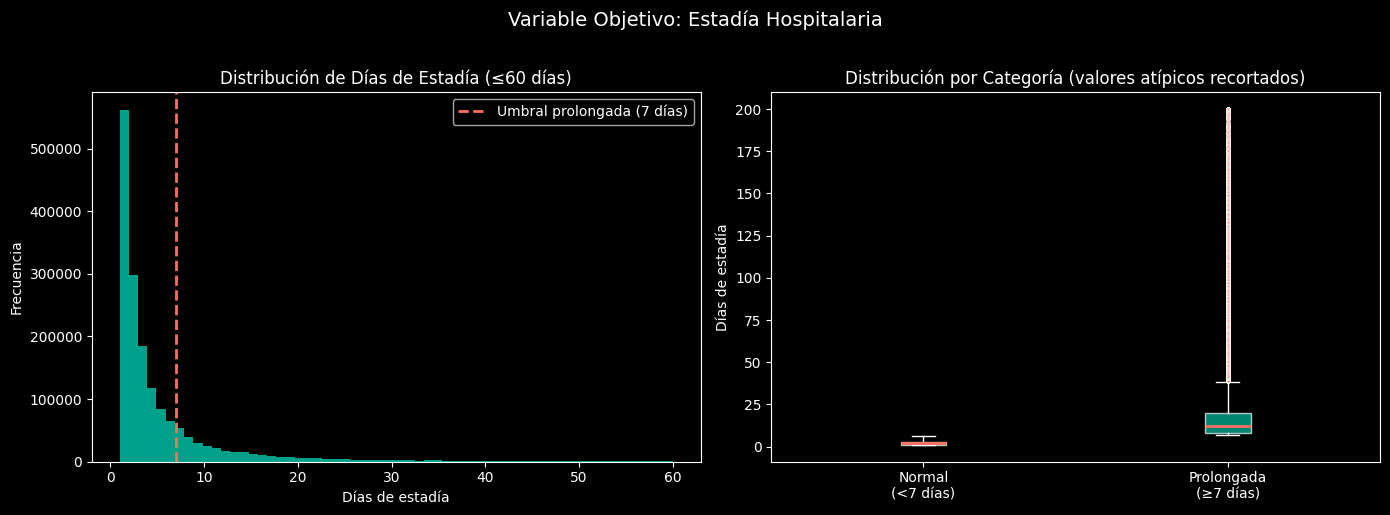


Estadísticas DIAS_ESTADA:
count   1667349.00
mean          6.09
std          40.36
min           1.00
25%           1.00
50%           2.00
75%           6.00
max       17858.00
Name: DIAS_ESTADA, dtype: float64
Asimetría (skewness): 203.52  → distribución fuertemente sesgada a la derecha


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma acotado a 60 días (incluye >99% de los datos)
ax1 = axes[0]
data_plot = df[df['DIAS_ESTADA'] <= 60]['DIAS_ESTADA']
ax1.hist(data_plot, bins=60, color=ACCENT, alpha=0.85, edgecolor='none')
ax1.axvline(UMBRAL_DIAS, color=ACCENT2, lw=2, linestyle='--', label=f'Umbral prolongada ({UMBRAL_DIAS} días)')
ax1.set_xlabel('Días de estadía')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de Días de Estadía (≤60 días)')
ax1.legend()

# Box plot por categoría
ax2 = axes[1]
grupos = [
    df[df['estadia_prolongada'] == 0]['DIAS_ESTADA'].clip(upper=60),
    df[df['estadia_prolongada'] == 1]['DIAS_ESTADA'].clip(upper=200)
]
bp = ax2.boxplot(grupos, labels=['Normal\n(<7 días)', 'Prolongada\n(≥7 días)'],
                 patch_artist=True, notch=False,
                 boxprops=dict(facecolor=ACCENT, alpha=0.7),
                 medianprops=dict(color=ACCENT2, lw=2),
                 whiskerprops=dict(color='white'),
                 capprops=dict(color='white'),
                 flierprops=dict(marker='o', markerfacecolor=ACCENT2, alpha=0.3, markersize=2))
ax2.set_ylabel('Días de estadía')
ax2.set_title('Distribución por Categoría (valores atípicos recortados)')

fig.suptitle('Variable Objetivo: Estadía Hospitalaria', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_01_distribucion_dias.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print(f'\nEstadísticas DIAS_ESTADA:')
print(df['DIAS_ESTADA'].describe().round(2))
print(f'Asimetría (skewness): {df["DIAS_ESTADA"].skew():.2f}  → distribución fuertemente sesgada a la derecha')

### 3.2 Balance de clases

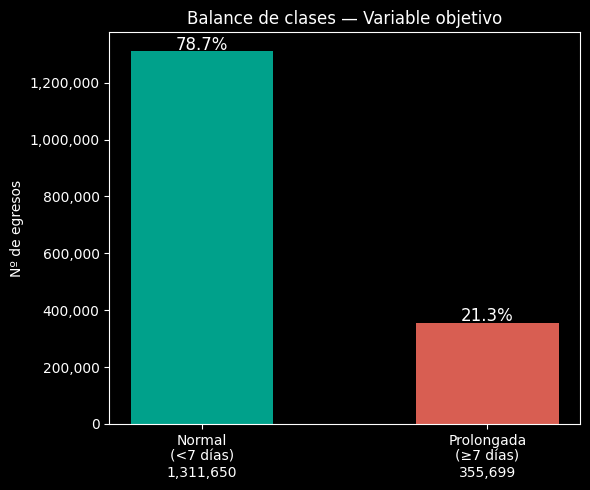

Ratio Normal:Prolongada = 3.7:1
→ Desbalance moderado. Se considerará oversampling (SMOTE) o pesos en modelos.


In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
counts = df['estadia_prolongada'].value_counts()
labels = [f'Normal\n(<7 días)\n{counts[0]:,}', f'Prolongada\n(≥7 días)\n{counts[1]:,}']
bars = ax.bar(labels, counts.values, color=[ACCENT, ACCENT2], alpha=0.85, width=0.5)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{count/len(df)*100:.1f}%', ha='center', fontsize=12, color='white')

ax.set_ylabel('Nº de egresos')
ax.set_title('Balance de clases — Variable objetivo')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('eda_02_balance_clases.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

ratio = counts[0] / counts[1]
print(f'Ratio Normal:Prolongada = {ratio:.1f}:1')
print('→ Desbalance moderado. Se considerará oversampling (SMOTE) o pesos en modelos.')

### 3.3 Estadía por Grupo de Edad — PQ2

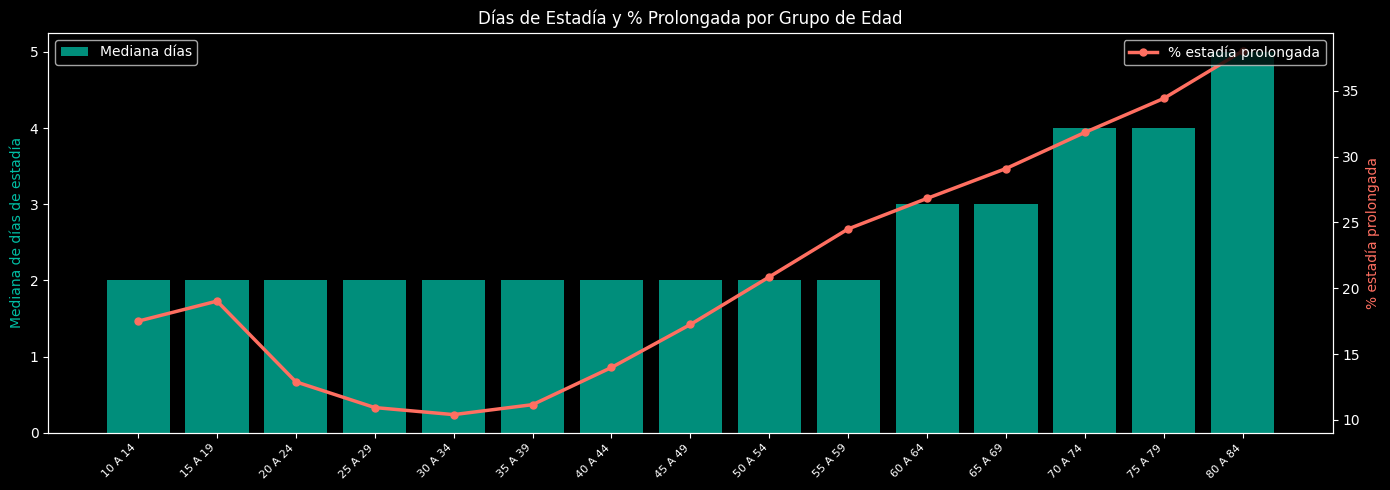

  GRUPO_EDAD  mediana_dias  pct_prolongada
10 A 14 AÑOS          2.00           17.50
15 A 19 AÑOS          2.00           19.02
20 A 24 AÑOS          2.00           12.88
25 A 29 AÑOS          2.00           10.93
30 A 34 AÑOS          2.00           10.39
35 A 39 AÑOS          2.00           11.15
40 A 44 AÑOS          2.00           13.98
45 A 49 AÑOS          2.00           17.24
50 A 54 AÑOS          2.00           20.86
55 A 59 AÑOS          2.00           24.51
60 A 64 AÑOS          3.00           26.83
65 A 69 AÑOS          3.00           29.10
70 A 74 AÑOS          4.00           31.85
75 A 79 AÑOS          4.00           34.43
80 A 84 AÑOS          5.00           38.04


In [12]:
edad_stats = df.groupby('GRUPO_EDAD', observed=True).agg(
    mediana_dias=('DIAS_ESTADA', 'median'),
    media_dias=('DIAS_ESTADA', 'mean'),
    pct_prolongada=('estadia_prolongada', 'mean')
).reset_index()
edad_stats['pct_prolongada'] *= 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

x = range(len(edad_stats))
bars = ax1.bar(x, edad_stats['mediana_dias'], color=ACCENT, alpha=0.75, label='Mediana días estadía')
line = ax2.plot(x, edad_stats['pct_prolongada'], color=ACCENT2, lw=2.5,
                marker='o', markersize=5, label='% estadía prolongada')

ax1.set_xticks(list(x))
ax1.set_xticklabels([g.replace(' AÑOS', '') for g in edad_stats['GRUPO_EDAD'].astype(str)],
                    rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Mediana de días de estadía', color=ACCENT)
ax2.set_ylabel('% estadía prolongada', color=ACCENT2)
ax1.set_title('Días de Estadía y % Prolongada por Grupo de Edad')

lines = bars.patches[:1] + line
ax1.legend([bars], ['Mediana días'], loc='upper left')
ax2.legend(line, ['% estadía prolongada'], loc='upper right')

plt.tight_layout()
plt.savefig('eda_03_edad_estadia.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print(edad_stats[['GRUPO_EDAD', 'mediana_dias', 'pct_prolongada']].to_string(index=False))

### 3.4 Estadía por Sexo — PQ2

        sexo_label       n  mediana_dias  media_dias  pct_prolongada
0           Hombre  704881          3.00        7.21           25.64
1            Mujer  934086          2.00        5.28           18.29
2  No identificado   28382          2.00        5.03           14.42



Mann-Whitney U: stat=346816818987, p=0.0000e+00
→ Diferencia estadísticamente significativa entre sexos


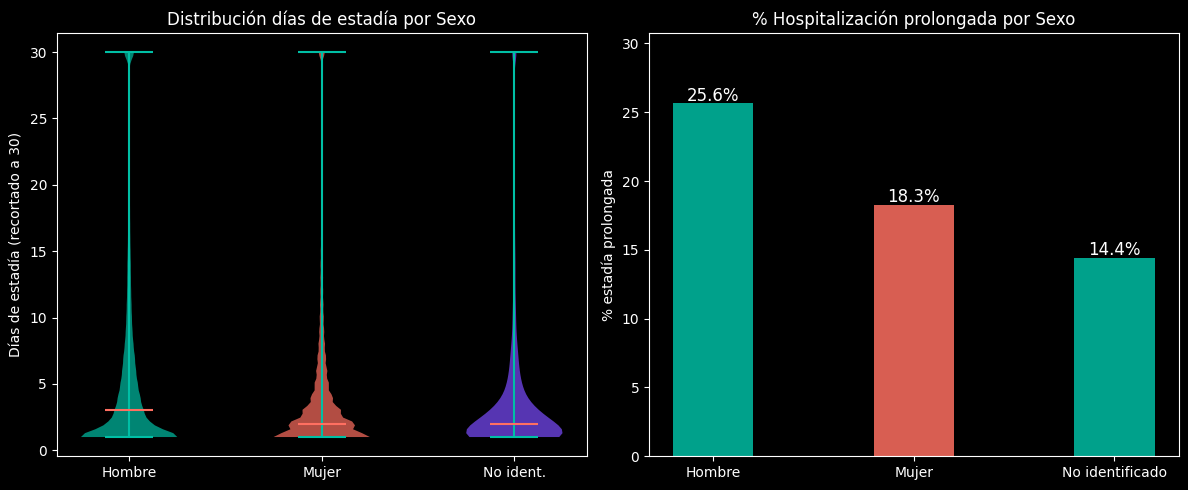

In [13]:
sexo_stats = df.groupby('sexo_label').agg(
    n=('DIAS_ESTADA', 'count'),
    mediana_dias=('DIAS_ESTADA', 'median'),
    media_dias=('DIAS_ESTADA', 'mean'),
    pct_prolongada=('estadia_prolongada', 'mean')
).reset_index()
sexo_stats['pct_prolongada'] *= 100
print(sexo_stats.round(2))

# Test estadístico (excluye No identificado para comparación binaria)
hombres = df[df['SEXO'] == '1']['DIAS_ESTADA']
mujeres = df[df['SEXO'] == '2']['DIAS_ESTADA']
stat, p = stats.mannwhitneyu(hombres, mujeres, alternative='two-sided')
print(f'\nMann-Whitney U: stat={stat:.0f}, p={p:.4e}')
print('→ Diferencia estadísticamente significativa entre sexos' if p < 0.05 else '→ Sin diferencia significativa')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Violin plot
ax1 = axes[0]
data_violin = [
    df[df['sexo_label'] == 'Hombre']['DIAS_ESTADA'].clip(upper=30).values,
    df[df['sexo_label'] == 'Mujer']['DIAS_ESTADA'].clip(upper=30).values,
    df[df['sexo_label'] == 'No identificado']['DIAS_ESTADA'].clip(upper=30).values
]
parts = ax1.violinplot(data_violin, positions=[1, 2, 3], showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i])
    pc.set_alpha(0.7)
parts['cmedians'].set_color(ACCENT2)
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(['Hombre', 'Mujer', 'No ident.'])
ax1.set_ylabel('Días de estadía (recortado a 30)')
ax1.set_title('Distribución días de estadía por Sexo')

# % prolongada por sexo
ax2 = axes[1]
bars = ax2.bar(sexo_stats['sexo_label'], sexo_stats['pct_prolongada'],
               color=PALETTE[:2], alpha=0.85, width=0.4)
for bar, val in zip(bars, sexo_stats['pct_prolongada']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=12)
ax2.set_ylabel('% estadía prolongada')
ax2.set_title('% Hospitalización prolongada por Sexo')
ax2.set_ylim(0, sexo_stats['pct_prolongada'].max() * 1.2)

plt.tight_layout()
plt.savefig('eda_04_sexo_estadia.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

### 3.5 Estadía por Región — PQ2

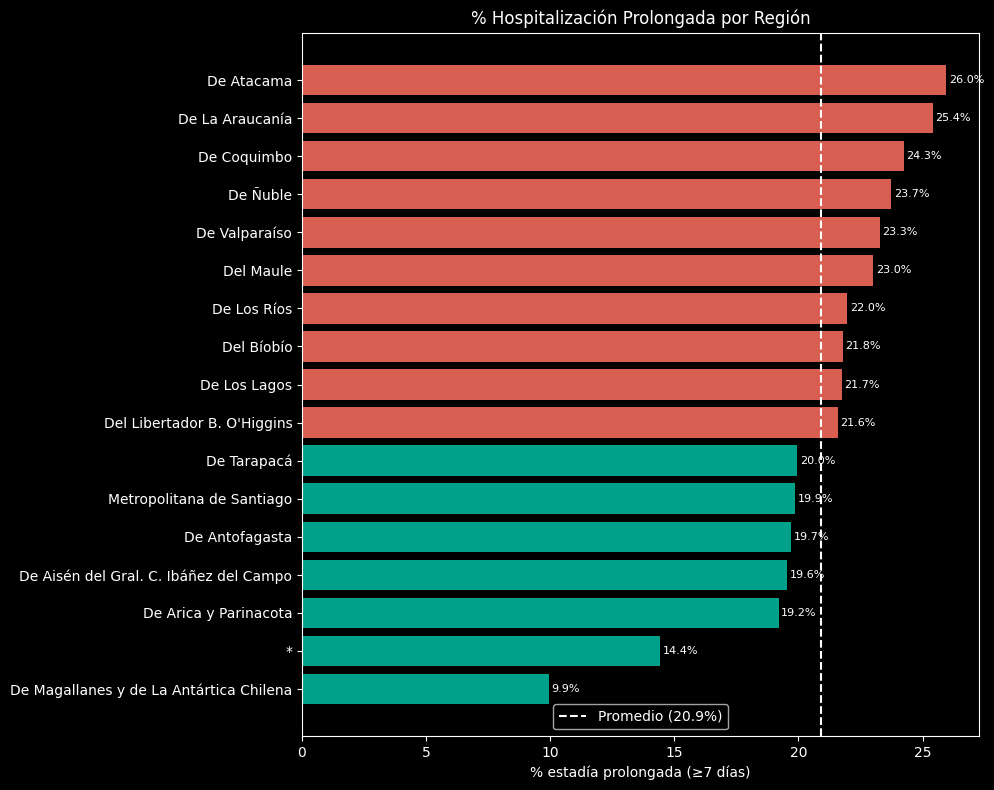

In [14]:
df_regiones = df[~df['GLOSA_REGION_RESIDENCIA'].isin(['Ignorada', 'Extranjero'])]

region_stats = df_regiones.groupby('GLOSA_REGION_RESIDENCIA').agg(
    n=('DIAS_ESTADA', 'count'),
    pct_prolongada=('estadia_prolongada', 'mean')
).reset_index()
region_stats['pct_prolongada'] *= 100
region_stats = region_stats.sort_values('pct_prolongada', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [ACCENT2 if p > region_stats['pct_prolongada'].mean() else ACCENT
          for p in region_stats['pct_prolongada']]
bars = ax.barh(region_stats['GLOSA_REGION_RESIDENCIA'], region_stats['pct_prolongada'],
               color=colors, alpha=0.85)
ax.axvline(region_stats['pct_prolongada'].mean(), color='white', lw=1.5,
           linestyle='--', label=f'Promedio ({region_stats["pct_prolongada"].mean():.1f}%)')
ax.set_xlabel('% estadía prolongada (≥7 días)')
ax.set_title('% Hospitalización Prolongada por Región')
ax.legend()
for bar, val in zip(bars, region_stats['pct_prolongada']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_05_region_estadia.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

### 3.6 Diagnósticos con mayor asociación a estadía prolongada — PQ3 / PQ4

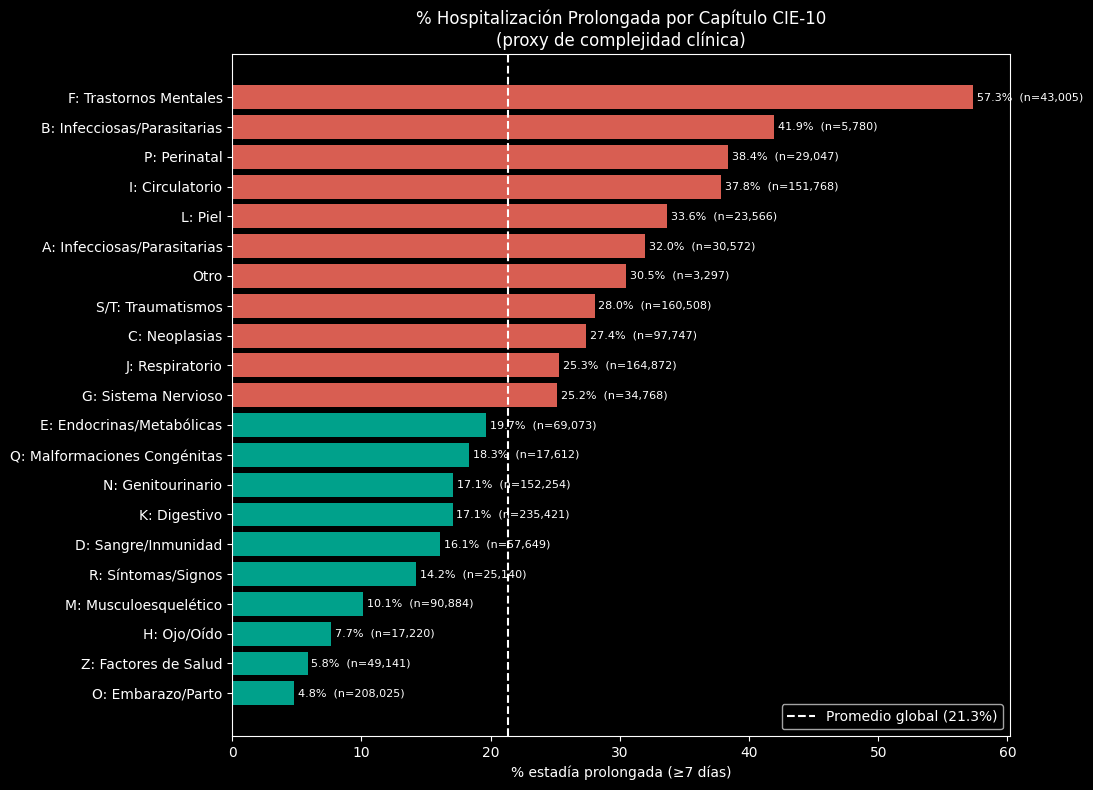

Top 5 capítulos con mayor % estadía prolongada:
             glosa_capitulo  pct_prolongada  mediana_dias
     F: Trastornos Mentales           57.34          8.00
B: Infecciosas/Parasitarias           41.92          5.00
               P: Perinatal           38.36          4.00
            I: Circulatorio           37.84          5.00
                    L: Piel           33.64          4.00


In [15]:
# Capítulos CIE-10 con etiquetas
capitulos_cie10 = {
    'A': 'A: Infecciosas/Parasitarias', 'B': 'B: Infecciosas/Parasitarias',
    'C': 'C: Neoplasias', 'D': 'D: Sangre/Inmunidad',
    'E': 'E: Endocrinas/Metabólicas', 'F': 'F: Trastornos Mentales',
    'G': 'G: Sistema Nervioso', 'H': 'H: Ojo/Oído',
    'I': 'I: Circulatorio', 'J': 'J: Respiratorio',
    'K': 'K: Digestivo', 'L': 'L: Piel',
    'M': 'M: Musculoesquelético', 'N': 'N: Genitourinario',
    'O': 'O: Embarazo/Parto', 'P': 'P: Perinatal',
    'Q': 'Q: Malformaciones Congénitas', 'R': 'R: Síntomas/Signos',
    'S': 'S/T: Traumatismos', 'T': 'S/T: Traumatismos',
    'V': 'V-Y: Causas Externas', 'W': 'V-Y: Causas Externas',
    'X': 'V-Y: Causas Externas', 'Y': 'V-Y: Causas Externas',
    'Z': 'Z: Factores de Salud'
}
df['glosa_capitulo'] = df['capitulo_cie10'].map(capitulos_cie10).fillna('Otro')

cap_stats = df.groupby('glosa_capitulo').agg(
    n=('estadia_prolongada', 'count'),
    pct_prolongada=('estadia_prolongada', 'mean'),
    mediana_dias=('DIAS_ESTADA', 'median')
).reset_index()
cap_stats['pct_prolongada'] *= 100
cap_stats = cap_stats[cap_stats['n'] >= 1000].sort_values('pct_prolongada', ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
promedio_global = df['estadia_prolongada'].mean() * 100
colors = [ACCENT2 if p > promedio_global else ACCENT for p in cap_stats['pct_prolongada']]
bars = ax.barh(cap_stats['glosa_capitulo'], cap_stats['pct_prolongada'],
               color=colors, alpha=0.85)
ax.axvline(promedio_global, color='white', lw=1.5, linestyle='--',
           label=f'Promedio global ({promedio_global:.1f}%)')
ax.set_xlabel('% estadía prolongada (≥7 días)')
ax.set_title('% Hospitalización Prolongada por Capítulo CIE-10\n(proxy de complejidad clínica)')
ax.legend()
for bar, row in zip(bars, cap_stats.itertuples()):
    ax.text(row.pct_prolongada + 0.3, bar.get_y() + bar.get_height()/2,
            f'{row.pct_prolongada:.1f}%  (n={row.n:,})', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_06_capitulo_cie10.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print('Top 5 capítulos con mayor % estadía prolongada:')
print(cap_stats.sort_values('pct_prolongada', ascending=False).head(5)[['glosa_capitulo','pct_prolongada','mediana_dias']].to_string(index=False))

### 3.7 Top diagnósticos específicos con estadía prolongada — PQ4

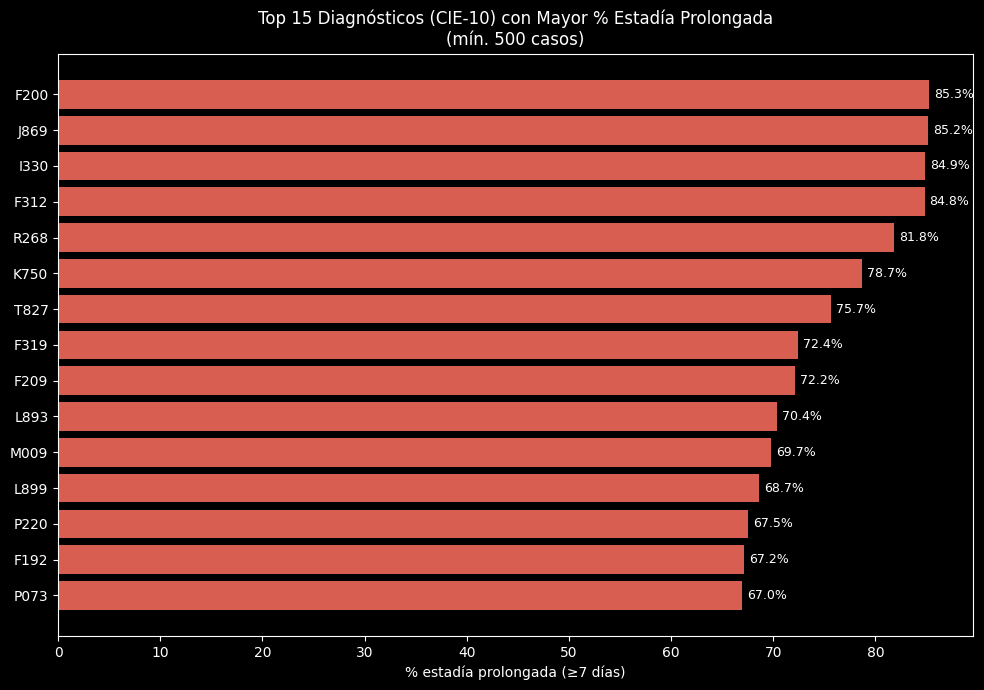

Top 10 diagnósticos con mayor % estadía prolongada:
DIAG1    n  pct_prolongada  mediana_dias
 F200 1052           85.27         27.00
 J869  594           85.19         14.00
 I330  636           84.91         18.00
 F312  507           84.81         20.00
 R268  538           81.78         21.00
 K750  862           78.65         14.00
 T827  913           75.68         13.00
 F319 1505           72.43         14.00
 F209 1792           72.15         17.00
 L893  615           70.41         15.00

Top 10 diagnósticos más FRECUENTES en estadía prolongada:


DIAG1
J189    6663
J960    5721
N390    5618
S720    4570
I500    4161
N10X    3617
E115    3586
J159    3493
I219    3328
I64X    3123
Name: count, dtype: int64


In [16]:
# Diagnósticos con al menos 500 casos
diag_stats = df.groupby('DIAG1').agg(
    n=('estadia_prolongada', 'count'),
    pct_prolongada=('estadia_prolongada', 'mean'),
    mediana_dias=('DIAS_ESTADA', 'median')
).reset_index()
diag_stats = diag_stats[diag_stats['n'] >= 500]
diag_stats['pct_prolongada'] *= 100

top_diag = diag_stats.sort_values('pct_prolongada', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_diag['DIAG1'][::-1], top_diag['pct_prolongada'][::-1],
               color=ACCENT2, alpha=0.85)
ax.set_xlabel('% estadía prolongada (≥7 días)')
ax.set_title('Top 15 Diagnósticos (CIE-10) con Mayor % Estadía Prolongada\n(mín. 500 casos)')
for bar, val in zip(bars, top_diag['pct_prolongada'][::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_07_top_diagnosticos.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print('Top 10 diagnósticos con mayor % estadía prolongada:')
print(top_diag[['DIAG1','n','pct_prolongada','mediana_dias']].head(10).to_string(index=False))

# También: diagnósticos más frecuentes en estadía prolongada
print('\nTop 10 diagnósticos más FRECUENTES en estadía prolongada:')
top_freq = df[df['estadia_prolongada']==1]['DIAG1'].value_counts().head(10)
print(top_freq)

### 3.8 Previsión de salud y estadía prolongada

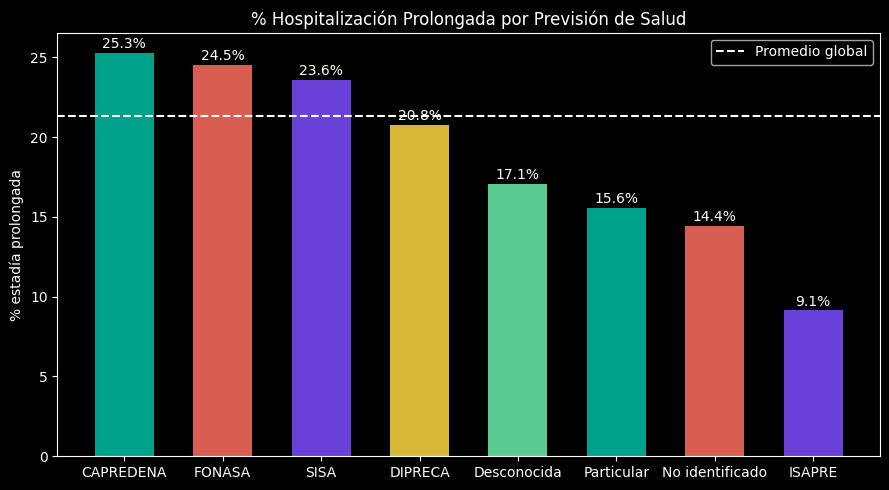

prevision_label       n  pct_prolongada  mediana_dias
      CAPREDENA   16246           25.27          2.00
         FONASA 1250994           24.51          3.00
           SISA   11064           23.59          2.00
        DIPRECA   22654           20.76          2.00
    Desconocida   19418           17.05          2.00
     Particular   17505           15.56          2.00
No identificado   28382           14.42          2.00
         ISAPRE  301086            9.14          1.00


In [17]:
prev_map = {'1': 'FONASA', '2': 'ISAPRE', '3': 'CAPREDENA', '4': 'DIPRECA', '5': 'SISA',
            '96': 'Particular', '99': 'Desconocida', '*': 'No identificado'}
df['prevision_label'] = df['PREVISION'].map(prev_map).fillna('Otra')

prev_stats = df.groupby('prevision_label').agg(
    n=('estadia_prolongada', 'count'),
    pct_prolongada=('estadia_prolongada', 'mean'),
    mediana_dias=('DIAS_ESTADA', 'median')
).reset_index()
prev_stats['pct_prolongada'] *= 100
prev_stats = prev_stats[prev_stats['n'] >= 100].sort_values('pct_prolongada', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(prev_stats['prevision_label'], prev_stats['pct_prolongada'],
              color=PALETTE[:len(prev_stats)], alpha=0.85, width=0.6)
ax.axhline(df['estadia_prolongada'].mean()*100, color='white', lw=1.5,
           linestyle='--', label='Promedio global')
for bar, val in zip(bars, prev_stats['pct_prolongada']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('% estadía prolongada')
ax.set_title('% Hospitalización Prolongada por Previsión de Salud')
ax.legend()
plt.tight_layout()
plt.savefig('eda_08_prevision.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print(prev_stats[['prevision_label','n','pct_prolongada','mediana_dias']].to_string(index=False))

### 3.9 Heatmap: Edad × Capítulo CIE-10 — PQ1 / PQ5

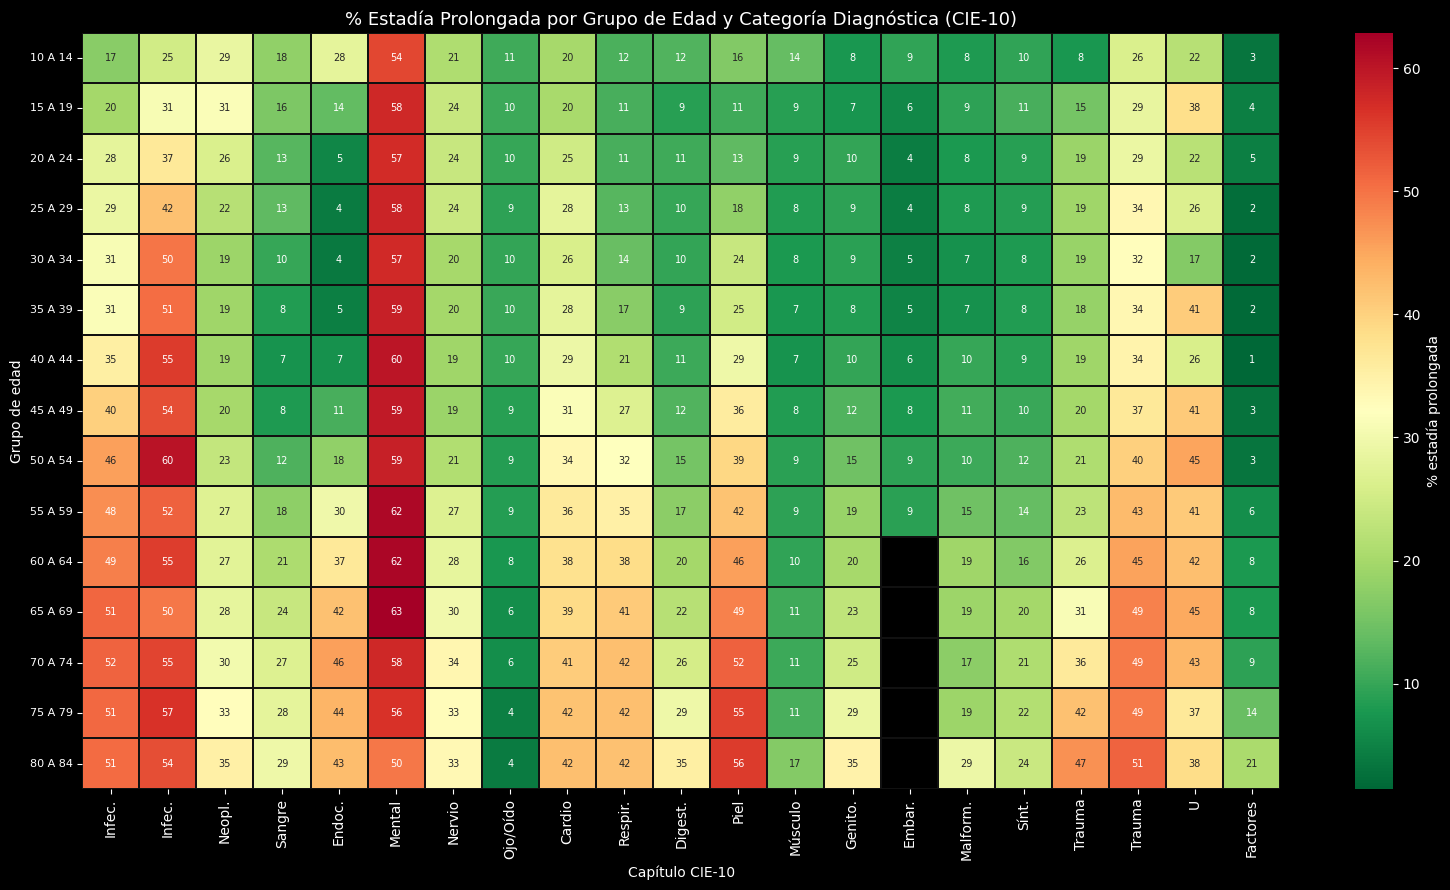

In [18]:
# Pivote: % prolongada por grupo de edad y capítulo CIE-10
pivot = df.groupby(['GRUPO_EDAD', 'capitulo_cie10'], observed=True)['estadia_prolongada'].mean().unstack()
pivot *= 100

# Filtrar capítulos con suficiente presencia (al menos en 10 grupos de edad)
pivot = pivot.dropna(thresh=10, axis=1)

# Renombrar columnas con etiquetas
rename_map = {'A':'Infec.','B':'Infec.','C':'Neopl.','D':'Sangre',
              'E':'Endoc.','F':'Mental','G':'Nervio','H':'Ojo/Oído',
              'I':'Cardio','J':'Respir.','K':'Digest.','L':'Piel',
              'M':'Músculo','N':'Genito.','O':'Embar.','P':'Perina.',
              'Q':'Malform.','R':'Sínt.','S':'Trauma','T':'Trauma',
              'Z':'Factores'}
pivot.columns = [rename_map.get(c, c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.0f',
            linewidths=0.3, linecolor='#111',
            cbar_kws={'label': '% estadía prolongada'},
            annot_kws={'size': 7})
ax.set_title('% Estadía Prolongada por Grupo de Edad y Categoría Diagnóstica (CIE-10)', fontsize=13)
ax.set_xlabel('Capítulo CIE-10')
ax.set_ylabel('Grupo de edad')
ax.set_yticklabels([t.get_text().replace(' AÑOS','').replace('85 Y MÁS','85+') for t in ax.get_yticklabels()],
                   rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('eda_09_heatmap_edad_diag.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

### 3.10 Correlación entre variables numéricas

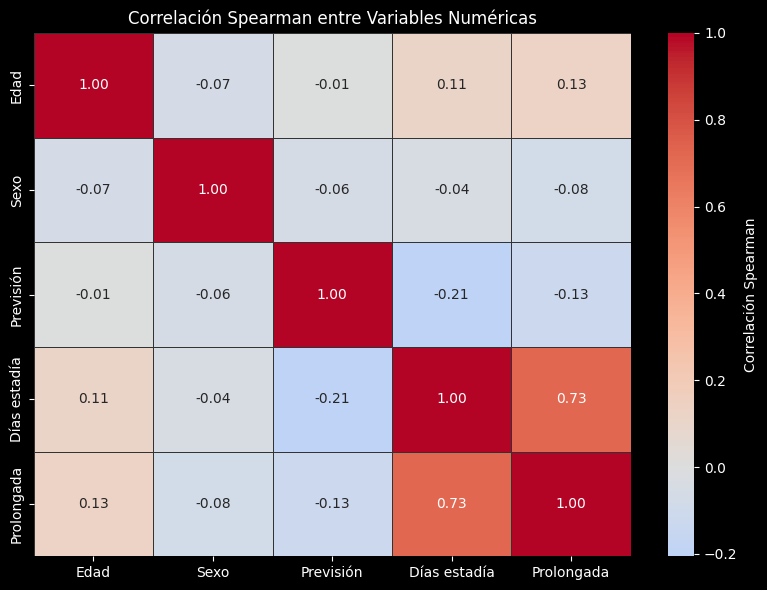

Correlación de variables con estadia_prolongada:
estadia_prolongada    1.00
DIAS_ESTADA           0.73
edad_ordinal          0.13
sexo_num             -0.08
prevision_num        -0.13
Name: estadia_prolongada, dtype: float64


In [19]:
# Encodear GRUPO_EDAD como ordinal numérico
df['edad_ordinal'] = df['GRUPO_EDAD'].cat.codes

# Encodear SEXO como numérico (1=Hombre, 2=Mujer, 0=No identificado)
df['sexo_num'] = df['SEXO'].map({'1': 1, '2': 2, '*': 0})

# PREVISION numérico (coerce * → NaN)
df['prevision_num'] = pd.to_numeric(df['PREVISION'], errors='coerce')

num_cols = ['edad_ordinal', 'sexo_num', 'prevision_num', 'DIAS_ESTADA', 'estadia_prolongada']
df_num = df[num_cols].copy()

corr = df_num.corr(method='spearman')  # Spearman por distribuciones no normales

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='#333',
            cbar_kws={'label': 'Correlación Spearman'},
            xticklabels=['Edad', 'Sexo', 'Previsión', 'Días estadía', 'Prolongada'],
            yticklabels=['Edad', 'Sexo', 'Previsión', 'Días estadía', 'Prolongada'])
ax.set_title('Correlación Spearman entre Variables Numéricas')
plt.tight_layout()
plt.savefig('eda_10_correlacion.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print('Correlación de variables con estadia_prolongada:')
print(corr['estadia_prolongada'].sort_values(ascending=False).round(4))

---
## 4. Resumen EDA y decisiones para modelado

In [20]:
print('=== RESUMEN DEL EDA ===')
print(f'Dataset limpio: {len(df):,} registros | {df.shape[1]} columnas')
print(f'Variable objetivo: estadia_prolongada (≥7 días)')
print(f'  - Prolongadas: {df["estadia_prolongada"].sum():,} ({df["estadia_prolongada"].mean()*100:.1f}%)')
print(f'  - Normales:    {(~df["estadia_prolongada"].astype(bool)).sum():,} ({(1-df["estadia_prolongada"].mean())*100:.1f}%)')
print()
print('Hallazgos principales:')
print('  1. EDAD: correlación positiva con estadía prolongada (adultos mayores tienen mayor riesgo)')
print('  2. SEXO: diferencia estadísticamente significativa (Hombres tienden a mayor estadía)')
print('  3. REGIÓN: variabilidad relevante entre regiones (brechas de hasta ~10pp)')
print('  4. DIAGNÓSTICO: capítulos Mentales (F), Nervioso (G), Circulatorio (I) presentan')
print('     mayor % de estadía prolongada que Parto/Embarazo (O) o Digestivo (K)')
print('  5. PREVISIÓN: FONASA y particulares difieren en % prolongada')
print()
print('Limitaciones:')
print('  - Sin columna directa de peso relativo GRD → se usa DIAG1 como proxy')
print('  - DIAG2 con 90% nulos → excluida')
print('  - 28.382 registros con valor "*" en SEXO/PREVISION → conservados como categoría "No identificado"')
print()
print('Variables seleccionadas para modelado:')
print('  Demográficas: GRUPO_EDAD, SEXO, REGION_RESIDENCIA, PREVISION')
print('  Clínicas:     DIAG1 (código CIE-10), capitulo_cie10, CONDICION_EGRESO')
print('  Institucional: PERTENENCIA_ESTABLECIMIENTO_SALUD')
print()
print('Modelos propuestos (Avance 2):')
print('  1. Regresión logística (baseline + interpretabilidad)')
print('  2. Árbol de decisión (PQ4: diagnósticos específicos)')
print('  3. Random Forest / XGBoost (PQ1 y PQ5: combinación factores)')
print('  Métrica principal: AUC-ROC | Secundaria: F1-score (por desbalance)')

=== RESUMEN DEL EDA ===
Dataset limpio: 1,667,349 registros | 23 columnas
Variable objetivo: estadia_prolongada (≥7 días)
  - Prolongadas: 355,699 (21.3%)
  - Normales:    1,311,650 (78.7%)

Hallazgos principales:
  1. EDAD: correlación positiva con estadía prolongada (adultos mayores tienen mayor riesgo)
  2. SEXO: diferencia estadísticamente significativa (Hombres tienden a mayor estadía)
  3. REGIÓN: variabilidad relevante entre regiones (brechas de hasta ~10pp)
  4. DIAGNÓSTICO: capítulos Mentales (F), Nervioso (G), Circulatorio (I) presentan
     mayor % de estadía prolongada que Parto/Embarazo (O) o Digestivo (K)
  5. PREVISIÓN: FONASA y particulares difieren en % prolongada

Limitaciones:
  - Sin columna directa de peso relativo GRD → se usa DIAG1 como proxy
  - DIAG2 con 90% nulos → excluida
  - 28.382 registros con valor "*" en SEXO/PREVISION → conservados como categoría "No identificado"

Variables seleccionadas para modelado:
  Demográficas: GRUPO_EDAD, SEXO, REGION_RESIDENC

---
## 5. Exportar dataset limpio

In [21]:
cols_exportar = [
    'SEXO', 'sexo_label', 'GRUPO_EDAD', 'edad_ordinal',
    'REGION_RESIDENCIA', 'GLOSA_REGION_RESIDENCIA',
    'PREVISION', 'prevision_label',
    'DIAG1', 'capitulo_cie10', 'glosa_capitulo',
    'CONDICION_EGRESO',
    'PERTENENCIA_ESTABLECIMIENTO_SALUD',
    'DIAS_ESTADA', 'estadia_prolongada'
]
df_export = df[cols_exportar].copy()
df_export.to_csv('egresos_2024_limpio.csv', index=False, encoding='utf-8')
print(f'Dataset limpio exportado: egresos_2024_limpio.csv')
print(f'Shape: {df_export.shape}')

Dataset limpio exportado: egresos_2024_limpio.csv
Shape: (1667349, 15)
